In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
meta_v2 = pd.read_csv(r"C:\Users\windows\Downloads\data_100k\processed\meta_v2.csv")

In [3]:
meta = meta_v2.copy()

print("Shape:", meta.shape)
meta.info()

Shape: (100000, 18)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   image_id              100000 non-null  str    
 1   image_url             100000 non-null  str    
 2   image_path            100000 non-null  str    
 3   dish_name             99998 non-null   str    
 4   category              100000 non-null  str    
 5   cooking_method        98642 non-null   str    
 6   sub_dt                100000 non-null  int64  
 7   food_prob             100000 non-null  float64
 8   camera_or_phone_prob  100000 non-null  float64
 9   ingredients_list      100000 non-null  str    
 10  ingredients_text_raw  99999 non-null   str    
 11  portion_list          100000 non-null  str    
 12  portion_text_raw      99999 non-null   str    
 13  calories_kcal         100000 non-null  int64  
 14  fat_g                 100000 non-null  float

In [4]:
meta.isna().sum().sort_values(ascending=False)

cooking_method          1358
dish_name                  2
portion_text_raw           1
ingredients_text_raw       1
image_url                  0
image_id                   0
sub_dt                     0
food_prob                  0
image_path                 0
category                   0
ingredients_list           0
camera_or_phone_prob       0
portion_list               0
calories_kcal              0
fat_g                      0
protein_g                  0
carbohydrate_g             0
file_exists                0
dtype: int64

In [5]:
meta['file_exists'].value_counts()

file_exists
True     99572
False      428
Name: count, dtype: int64

In [6]:
meta = meta[meta['file_exists']]

In [7]:
nutrition_cols = ['calories_kcal','fat_g','protein_g','carbohydrate_g']
meta[nutrition_cols].describe()

,calories_kcal,fat_g,protein_g,carbohydrate_g
count,99572.000000,99572.000000,99572.000000,99572.000000
mean,411.829420,17.616962,21.430447,40.552638
std,256.497184,15.011400,18.107144,29.104189
min,0.000000,0.000000,0.000000,0.000000
25%,250.000000,10.000000,5.000000,20.000000
50%,350.000000,15.000000,20.000000,35.000000
75%,600.000000,25.000000,30.000000,60.000000
max,3500.000000,250.000000,250.000000,650.000000


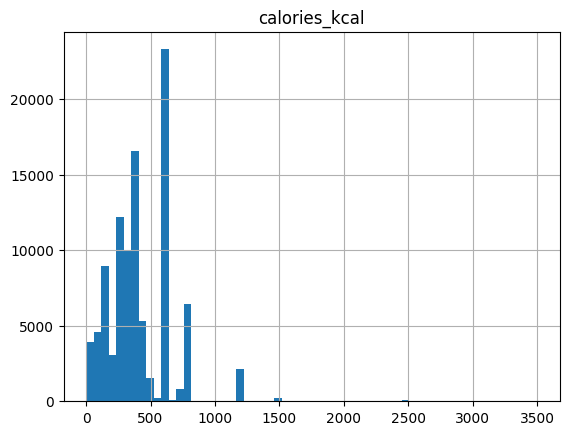

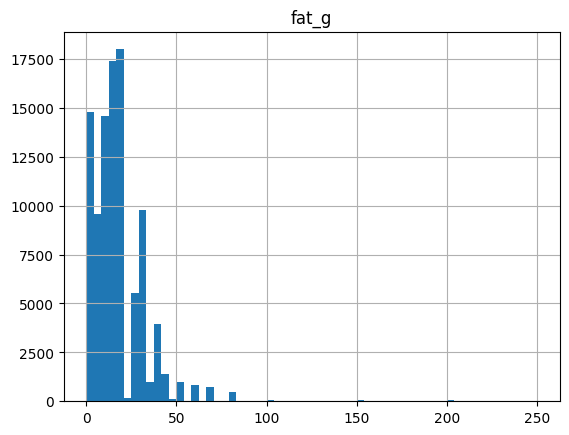

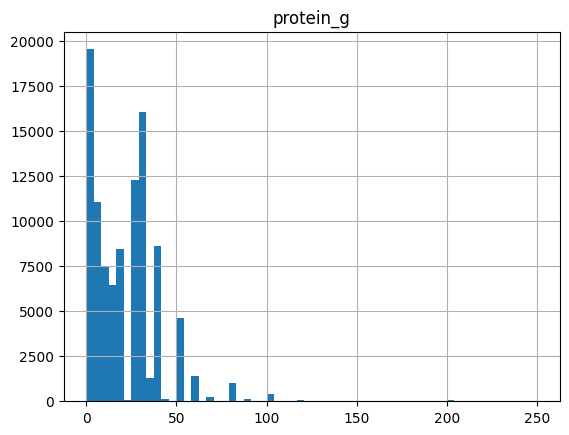

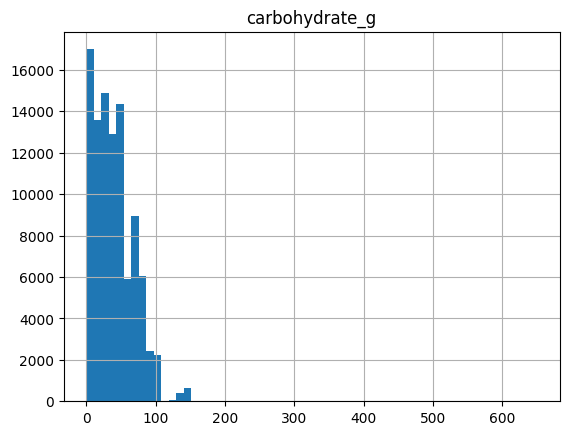

In [8]:
for col in nutrition_cols:
    plt.figure()
    meta[col].hist(bins=60)
    plt.title(col)
    plt.show()


In [9]:
for col in nutrition_cols:
    print(col)
    print("Skew:", meta[col].skew())
    print()


calories_kcal
Skew: 1.7036469767833864

fat_g
Skew: 2.794736019461566

protein_g
Skew: 1.9710372432034056

carbohydrate_g
Skew: 1.4221431137859306



In [10]:
meta['cal_from_macro'] = (
    9*meta['fat_g'] +
    4*meta['protein_g'] +
    4*meta['carbohydrate_g']
)

meta['cal_error'] = meta['calories_kcal'] - meta['cal_from_macro']

meta['cal_error'].describe()


count    99572.000000
mean         5.344421
std         39.517018
min      -1833.000000
25%        -10.000000
50%          0.000000
75%         20.000000
max       2114.400000
Name: cal_error, dtype: float64

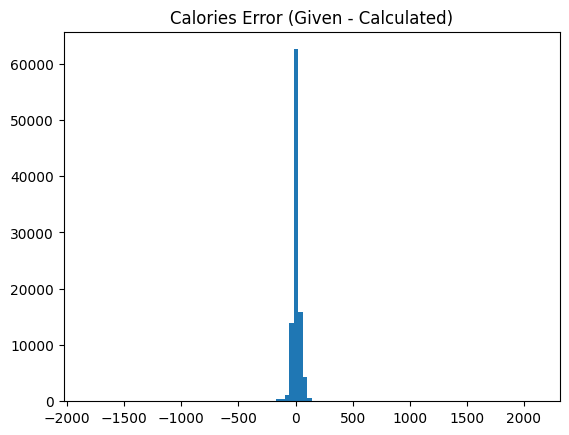

In [11]:
plt.hist(meta['cal_error'], bins=100)
plt.title("Calories Error (Given - Calculated)")
plt.show()


In [12]:
meta['category'].value_counts().head(20)


category
Homemade food                46315
Restaurant food              35408
Raw vegetables and fruits     9239
Packaged food                 8337
Others                         273
Name: count, dtype: int64

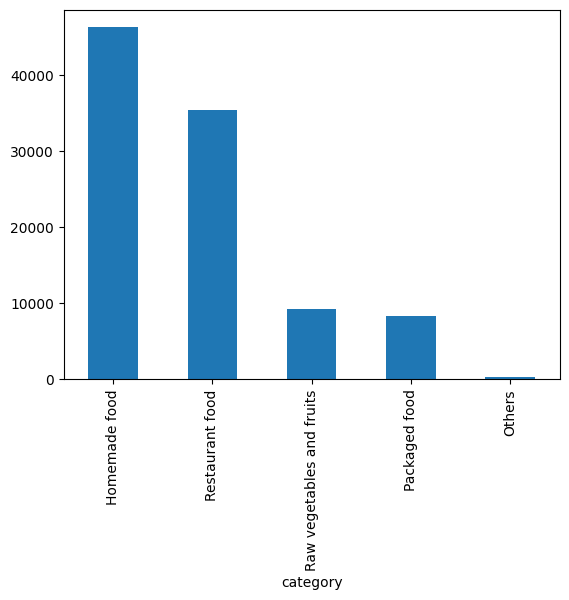

In [13]:
meta['category'].value_counts().plot(kind='bar')
plt.xticks(rotation=90)
plt.show()


In [14]:
meta['cooking_method'].value_counts()


cooking_method
Raw                             11471
boiling                          7126
Fried                            6272
Stir-frying                      5883
stir-frying                      5324
                                ...  
Grilled, sautéed, and boiled        1
stir-fry or hot pot                 1
Stir-Fried                          1
rolled and lightly fried            1
microwave or boiling                1
Name: count, Length: 2263, dtype: int64

In [15]:
meta['dish_name'].nunique()


19235

In [16]:
meta['dish_name'].value_counts().head(20)


dish_name
Noodle Soup                           1951
Dumplings                             1231
Hot Pot                                995
Stir-fried Noodles                     796
Fried Chicken                          711
Watermelon                             695
Apple                                  690
Pizza                                  609
Fried Rice                             609
Beef Noodle Soup                       582
Lychee                                 564
Mixed Asian Cuisine                    530
Grilled Meat Skewers                   520
Seafood Platter                        420
Strawberries                           400
Stir-fried Chicken with Vegetables     399
Braised Pork Belly                     397
Beef Stir-Fry                          388
Braised Pork                           384
Vegetable Stir-Fry                     360
Name: count, dtype: int64

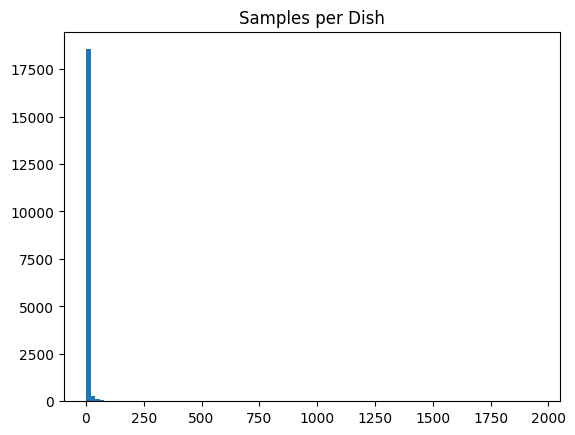

In [17]:
dish_counts = meta['dish_name'].value_counts()

plt.hist(dish_counts, bins=100)
plt.title("Samples per Dish")
plt.show()


In [18]:
meta['ingredient_count'] = meta['ingredients_list'].apply(len)

meta['ingredient_count'].describe()


count    99572.000000
mean        40.283523
std         17.157989
min          2.000000
25%         30.000000
50%         42.000000
75%         52.000000
max        133.000000
Name: ingredient_count, dtype: float64

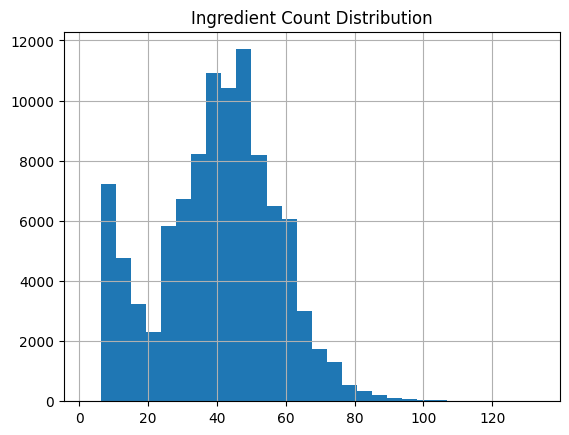

In [19]:
meta['ingredient_count'].hist(bins=30)
plt.title("Ingredient Count Distribution")
plt.show()


In [20]:
from collections import Counter

all_ingredients = []

for lst in meta['ingredients_list']:
    all_ingredients.extend(lst)

ingredient_freq = Counter(all_ingredients)

pd.DataFrame(ingredient_freq.most_common(20), columns=['ingredient','count'])


,ingredient,count
0,',705126
1,e,384661
2,,337032
3,",",253059
4,s,244482
5,a,184100
6,o,179132
7,r,175330
8,c,151359
9,i,151265


In [21]:
meta['portion_text_raw'].head(20)

0                                         chicken:300g
1              noodles:200g; beef:100g; vegetables:50g
2                            dumplings:300g; sauce:50g
3                       Bananas: 10 pieces (about 1kg)
4           noodles:300g; chicken:100g; vegetables:50g
5                 shrimp:150g; noodles:100g; sauce:50g
6     beef:200g; vegetables:150g; rice:100g; soup:200g
7                                         noodles:200g
8                   noodles:200g; broth with meat:250g
9                                        oranges: 100g
10                          pumpkin:300g; filling:100g
11                               eggs:200g; bread:100g
12                           baby corn:200g; sauce:50g
13               crab:300g; sauce:50g; vegetables:100g
14              bread:300g; meat:200g; vegetables:100g
15              corn:200g; eggs:100g; blueberries:150g
16                             chicken:500g; sauce:50g
17     noodles:200g; ground meat:100g; vegetables:150g
18        

In [22]:
meta['portion_count'] = meta['portion_list'].apply(len)

meta['portion_count'].describe()


count    99572.000000
mean        34.386846
std         16.605737
min          2.000000
25%         19.000000
50%         32.000000
75%         46.000000
max        142.000000
Name: portion_count, dtype: float64

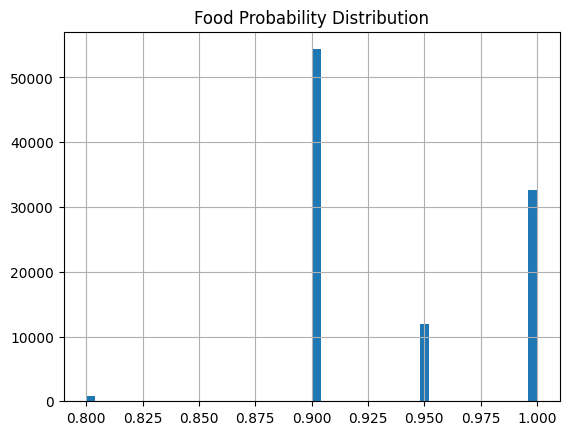

In [23]:
meta['food_prob'].hist(bins=50)
plt.title("Food Probability Distribution")
plt.show()


In [24]:
meta = meta[meta['food_prob'] > 0.8]


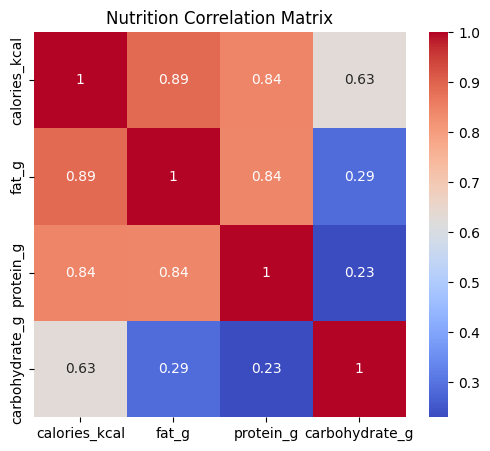

In [25]:
corr = meta[nutrition_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Nutrition Correlation Matrix")
plt.show()


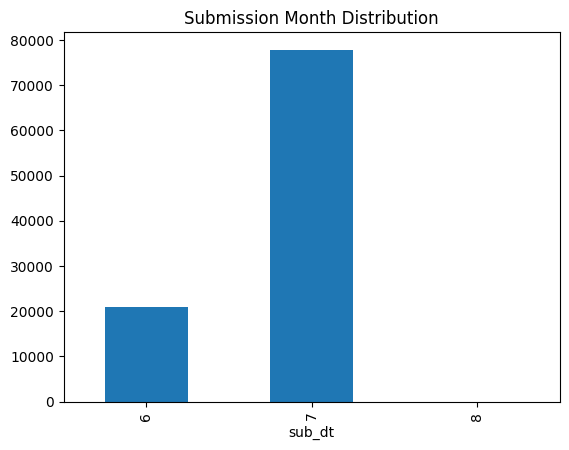

In [26]:
meta['sub_dt'] = pd.to_datetime(meta['sub_dt'], format='%Y%m%d')

meta['sub_dt'].dt.month.value_counts().sort_index().plot(kind='bar')
plt.title("Submission Month Distribution")
plt.show()
